# The Monty Hall Problem 

This project is a part of course **Data Science and Analysis** (EP4130), instructed by **Dr. Shantanu Desai**.


## Introduction

In the Monty Hall problem, a contestant is presented with **three doors**. Behind one door is a **valuable prize (a car)**, and behind the other two are **goats**. The sequence of play is:

1. The contestant selects one door (but does not open it).
2. The host, who knows what is behind each door, opens one of the two remaining doors, always revealing a goat.
3. The contestant is then offered the choice to *stay* with their initial selection or *switch* to the other unopened door.

We seek the contestant's **probability of winning the car** under each strategy (**staying** vs. **switching**) from a theoretical perspective.

This project also explores the problem through **simulation**, **statistical testing**, **visualization**, and **extensions**(including **generalization** and **modeling human bias**).


## Notation and Setup

Let the doors be labeled $\{1,2,3\}$, and let $C$ denote the door hiding the car. Let $S$ be the door initially selected by the contestant, and let $H$ be the door opened by the host.

- $C \in \{1,2,3\}$, with $\Pr(C=i)=\frac{1}{3}$ for $i=1,2,3$.
- $S \in \{1,2,3\}$ is chosen uniformly at random by the contestant, so $\Pr(S=i)=\frac{1}{3}$.
- Given $(C,S)$, the host picks $H\neq S$ such that $H\neq C$ (i.e., he never opens the car door), breaking ties uniformly if both remaining doors have goats.


## Theoretical Interpretation

We wish to compute:

$$
P_{\text{stay}} = \Pr(\text{win car} \mid \text{contestant stays}), 
\quad
P_{\text{switch}} = \Pr(\text{win car} \mid \text{contestant switches}).
$$

### Staying

If the contestant stays, they win exactly when their initial pick was correct:

$$
P_{\text{stay}} = \Pr(S = C) = \frac{1}{3}.
$$

### Switching

If the contestant switches, they win whenever their initial pick was wrong. Indeed:

$$
P_{\text{switch}} = \Pr(\text{initial pick wrong}) = 1 - \Pr(S = C) = 1 - \frac{1}{3} = \frac{2}{3}.
$$

We can enumerate all equally likely pairs \((C, S)\):

| Case | Car \(C\) | Initial pick \(S\) | Host opens \(H\)          |
|------|-----------|---------------------|----------------------------|
| 1    | 1         | 1                   | either 2 or 3 (goat)       |
| 2    | 1         | 2                   | host must open 3           |
| 3    | 1         | 3                   | host must open 2           |
| 4    | 2         | 1                   | host must open 3           |
| 5    | 2         | 2                   | either 1 or 3              |
| 6    | 2         | 3                   | host must open 1           |
| 7    | 3         | 1                   | host must open 2           |
| 8    | 3         | 2                   | host must open 1           |
| 9    | 3         | 3                   | either 1 or 2              |

There are 9 equally likely cases. In cases where \(S = C\) (cases 1, 5, 9), staying wins; in the other 6 cases, switching wins. Hence:

$$
P_{\text{stay}} = \frac{3}{9} = \frac{1}{3},
\quad
P_{\text{switch}} = \frac{6}{9} = \frac{2}{3}.
$$


## Libraries

In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import entropy, chisquare
from scipy.optimize import curve_fit

random.seed(42)  # For reproducibility

## Simulation

To empirically validate the Monty Hall problem, we simulated the game for 100,000 independent trials. Each trial was randomly generated under the standard rules:

1. Randomly assign the prize to one of the three doors.
2. Randomly select a door as the contestant’s initial choice.
3. The host opens one of the two remaining doors that does *not* contain the prize.
4. Record whether the contestant would win by **switching** or by **sticking**.


### Data Generation

The resulting dataset includes the following columns:

- **Prize Door**: Door hiding the car (1–3)
- **Chosen Door**: Contestant’s initial pick (1–3)
- **Win by Switching**: Boolean (1 if switch wins, else 0)
- **Win by Sticking**: Boolean (1 if stay wins, else 0)


In [2]:
def simulate_monty_hall(num_simulations):
    data = []

    for i in range(num_simulations):
        # Randomly assign the door with the prize (1, 2, or 3)
        prize_door = random.randint(1, 3)
        
        # Contestant initially picks a door (1, 2, or 3)
        chosen_door = random.randint(1, 3)

        # The host opens a door that is neither the prize door nor the contestant's chosen door
        remaining_doors = [1, 2, 3]
        remaining_doors.remove(chosen_door)
        if prize_door in remaining_doors:
            remaining_doors.remove(prize_door)  # Host will not open the prize door
        door_host_opens = remaining_doors[0]  # Host opens the last remaining door

        # If contestant switches, they choose the other door that was not picked initially or opened by the host
        switch_door = [door for door in [1, 2, 3] if door not in [chosen_door, door_host_opens]][0]

        # Outcome if sticking with the initial choice
        win_by_sticking = 1 if chosen_door == prize_door else 0
        
        # Outcome if switching doors
        win_by_switching = 1 if switch_door == prize_door else 0

        # Store the results of this simulation
        data.append({
            "Simulation": i + 1,
            "Chosen Door": chosen_door,
            "Prize Door": prize_door,
            "Win by Sticking": win_by_sticking,
            "Win by Switching": win_by_switching,
        })

    return pd.DataFrame(data)

# Generate a dataset with a large number of simulations
num_simulations = 100000  # Adjust the number of simulations as needed
monty_df = simulate_monty_hall(num_simulations)

# Display the first few rows of the generated dataset
monty_df.head()


,Simulation,Chosen Door,Prize Door,Win by Sticking,Win by Switching
0,1,1,3,0,1
1,2,3,1,0,1
2,3,1,2,0,1
3,4,1,1,1,0
4,5,1,3,0,1


### Win rate calculation 

We calculated the overall win rates for the two strategies:

- Switch Win Rate: **66.46%**
- Stick Win Rate: **33.54%**

Switch Win Rate: 66.54%
Stick Win Rate: 33.46%


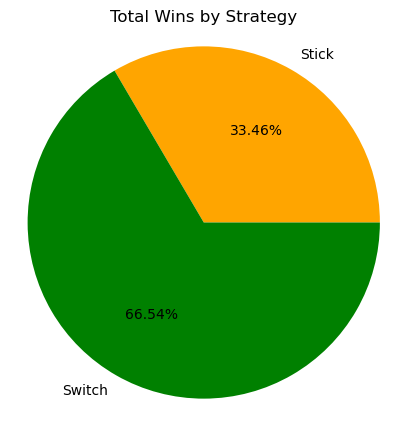

In [3]:
switch_win_rate = monty_df['Win by Switching'].mean() * 100
stick_win_rate = monty_df['Win by Sticking'].mean() * 100

print(f"Switch Win Rate: {switch_win_rate:.2f}%")
print(f"Stick Win Rate: {stick_win_rate:.2f}%")

wins = [stick_win_rate, switch_win_rate]
plt.figure(figsize=(5, 5))
plt.pie(wins, labels=['Stick', 'Switch'], autopct='%1.2f%%', colors=['orange', 'green'])
plt.title('Total Wins by Strategy')
plt.axis('equal')
plt.show()


### Win rate convergence over time 

We plotted the cumulative win rate over time for both strategies. 

As the number of simulations increased, **results converged to theoretical values**, demonstrating the law of large numbers in action.

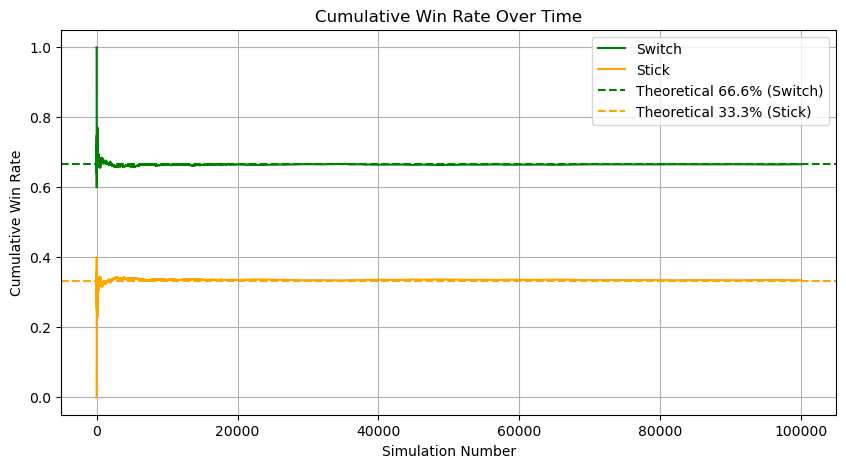

In [4]:
monty_df['Cumulative Win (Switch)'] = monty_df['Win by Switching'].cumsum() / monty_df['Simulation']
monty_df['Cumulative Win (Stick)'] = monty_df['Win by Sticking'].cumsum() / monty_df['Simulation']

plt.figure(figsize=(10, 5))
plt.plot(monty_df['Simulation'], monty_df['Cumulative Win (Switch)'], label='Switch', color='green')
plt.plot(monty_df['Simulation'], monty_df['Cumulative Win (Stick)'], label='Stick', color='orange')
plt.axhline(y=2/3, color='green', linestyle='--', label='Theoretical 66.6% (Switch)')
plt.axhline(y=1/3, color='orange', linestyle='--', label='Theoretical 33.3% (Stick)')
plt.title('Cumulative Win Rate Over Time')
plt.xlabel('Simulation Number')
plt.ylabel('Cumulative Win Rate')
plt.legend()
plt.grid(True)
plt.show()


As per plot, Switch and Stick win rate converges to $\frac{2}{3}$ and $\frac{1}{3}$, respectively.

## Statistical Analysis

### Batch simulation analysis 

**Interpretation:**

1. **Mean:** Across different batches, the win rate for Switching remains consistent at about 66%, and Sticking stays around 33%.

2. **Standard Deviation:** Low standard deviations suggest that the results are stable and do not vary wildly across batches, confirming that the simulation's behavior is consistent.



In [5]:
monty_df['Batch'] = pd.cut(monty_df['Simulation'], bins=10, labels=[f'Batch {i+1}' for i in range(10)])
batch_stats = monty_df.groupby('Batch')[['Win by Switching', 'Win by Sticking']].agg(['mean', 'std'])
batch_stats

Win by Switching           Win by Sticking          
                     mean       std            mean       std
Batch                                                        
Batch 1            0.6651  0.471979          0.3349  0.471979
Batch 2            0.6654  0.471874          0.3346  0.471874
Batch 3            0.6665  0.471487          0.3335  0.471487
Batch 4            0.6608  0.473461          0.3392  0.473461
Batch 5            0.6616  0.473189          0.3384  0.473189
Batch 6            0.6674  0.471168          0.3326  0.471168
Batch 7            0.6709  0.469910          0.3291  0.469910
Batch 8            0.6638  0.472432          0.3362  0.472432
Batch 9            0.6698  0.470308          0.3302  0.470308
Batch 10           0.6631  0.472674          0.3369  0.472674

**Distribution of Switch Win Rate Across Batches:**

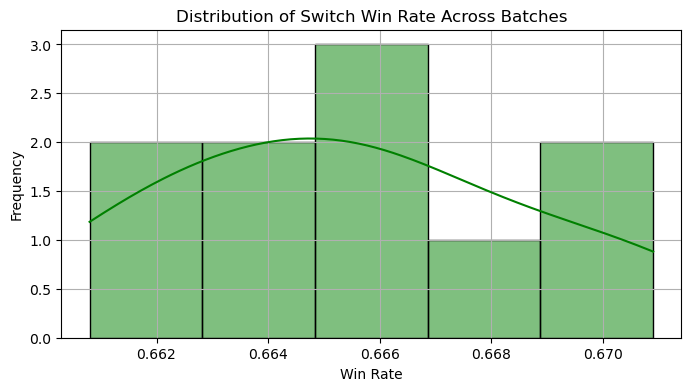

In [6]:
batch_means = batch_stats['Win by Switching']['mean']

plt.figure(figsize=(8, 4))
sns.histplot(batch_means, kde=True, color='green')
plt.title('Distribution of Switch Win Rate Across Batches')
plt.xlabel('Win Rate')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


Most batches win rate is near to 0.66 which matches the theoritical value (as per plot).

### Rate of Convergence

Emperical results converges to the theorical values very rapidly. We made two attempts to quatify the rapidness of the convergerce mathematically. 
1. **95% Confidence Interval Width**
2. **KL Divergence**

#### 95% Confidence Interval Width

We found that 95% Confidence Interval Width decreases with the sample size as follows:

$$
    95\% \text{ CI Width } \propto \frac{1}{\sqrt{\text{Sample Size}}}
$$

<!-- Stability of Results: The confidence intervals for both Switching and Sticking are quite narrow, indicating that the win rates for these strategies are stable and consistent across different resamples. This is expected since the Monty Hall problem has theoretical solutions around 66.6% for switching and 33.3% for sticking.

Effect of Switching vs Sticking:

Switching consistently provides a higher win rate (around 66%) with a small variation.

Sticking consistently gives a lower win rate (around 33%) with similarly small variation.

Statistical Robustness: The narrowness of the confidence intervals suggests that the simulation results are reliable and show strong evidence in favor of the Switch strategy being better than Stick. -->

95% Confidence Interval (Switching): (0.6625155312944562, 0.6683644687055439)
95% Confidence Interval (Sticking): (0.33163553129445617, 0.3374844687055439)


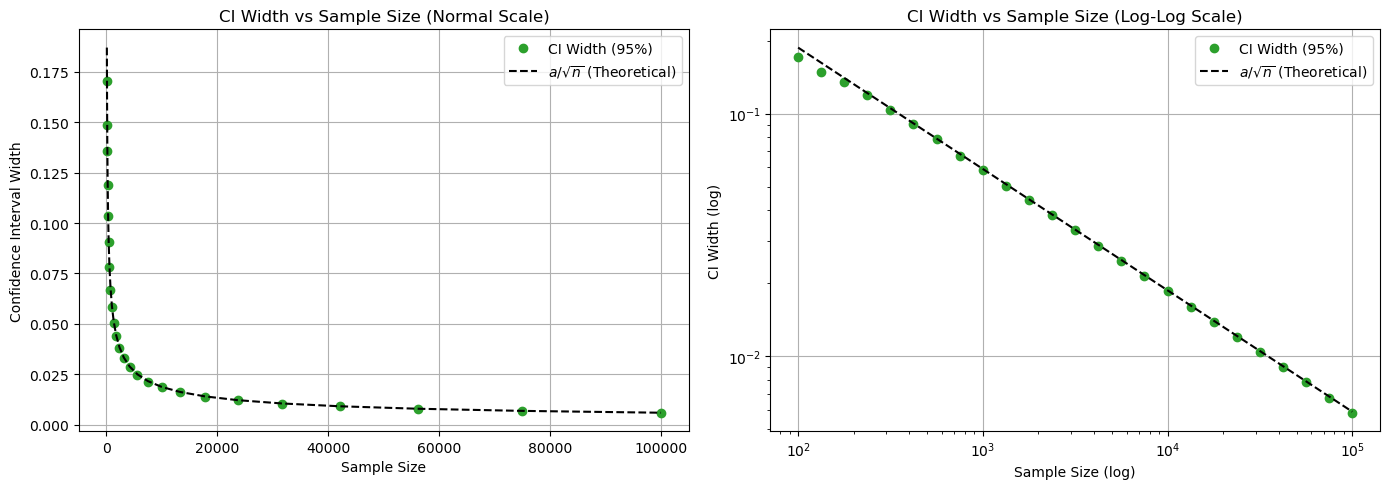

In [7]:
wins_switch = monty_df['Win by Switching'].to_numpy()

# Sample sizes to evaluate
sample_sizes = np.logspace(2, 5, 25, dtype=int)
ci_widths = []
theoretical_widths = []

# Compute confidence interval widths and theoretical 1/sqrt(n) line
for n in sample_sizes:
    sample = wins_switch[:n]
    mean = np.mean(sample)
    se = st.sem(sample)
    ci = st.t.interval(0.95, n-1, loc=mean, scale=se)
    ci_widths.append(ci[1] - ci[0])
    theoretical_widths.append(1.87 / np.sqrt(n))  # not scaled, relative // 1.87 is ideal

# Win Switchs
sample = monty_df['Win by Switching'].to_numpy()
mean = np.mean(sample)
se = st.sem(sample)
ci = st.t.interval(0.95, len(sample)-1, loc=mean, scale=se)
print(f"95% Confidence Interval (Switching): {ci}")

# Win Sticks
sample = monty_df['Win by Sticking'].to_numpy()
mean = np.mean(sample)
se = st.sem(sample)
ci = st.t.interval(0.95, len(sample)-1, loc=mean, scale=se)
print(f"95% Confidence Interval (Sticking): {ci}")

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Normal Scale ---
axs[0].plot(sample_sizes, ci_widths, label='CI Width (95%)', marker='o', linestyle='', color='tab:green')
axs[0].plot(sample_sizes, theoretical_widths, label=r'$a/\sqrt{n}$ (Theoretical)',  linestyle='--',  color='black')
axs[0].set_title("CI Width vs Sample Size (Normal Scale)")
axs[0].set_xlabel("Sample Size")
axs[0].set_ylabel("Confidence Interval Width")
axs[0].legend()
axs[0].grid(True)

# --- Log-Log Scale ---
axs[1].plot(sample_sizes, ci_widths, label='CI Width (95%)', marker='o', linestyle='', color='tab:green')
axs[1].plot(sample_sizes, theoretical_widths, label=r'$a/\sqrt{n}$ (Theoretical)', linestyle='--', color='black')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_title("CI Width vs Sample Size (Log-Log Scale)")
axs[1].set_xlabel("Sample Size (log)")
axs[1].set_ylabel("CI Width (log)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()



This plot shows how the Confidence Interval Width decreases with increase in sample size

#### KL Divergence

We found that KL Divergence between the *Observed Distribution* and *Theoretical Distribution* decreases with the sample size as follows:

$$
    \text{ KL( Observed Dist. || Theoretical Dist.) } \propto \frac{1}{\text{Sample Size}^{1.36}}
$$

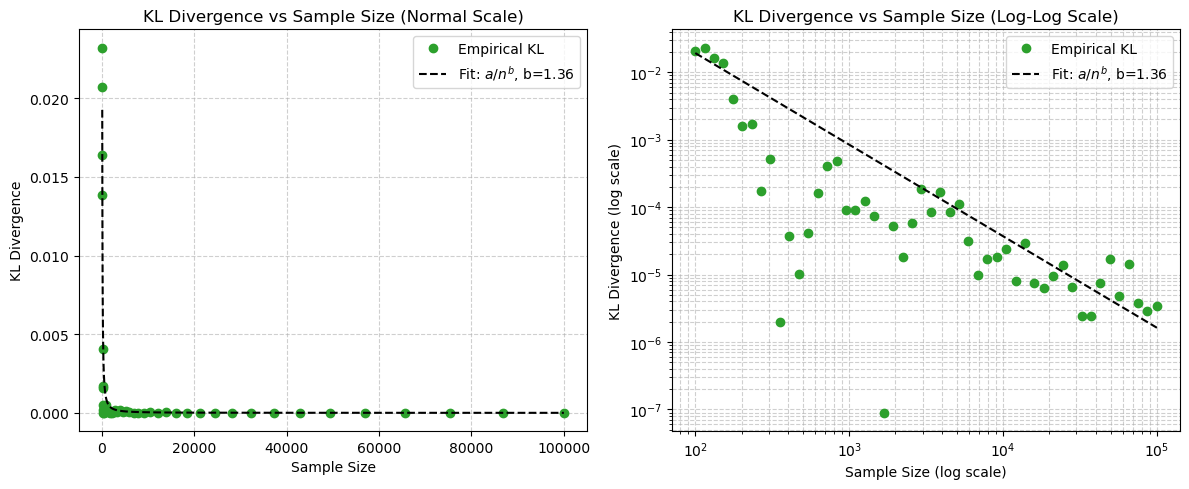

In [8]:
# KL Divergence
wins_switch = monty_df['Win by Switching'].to_numpy()

sample_sizes = np.logspace(2, 5, 50, dtype=int)
kl_divergences = []

theoretical_dist = np.array([2/3, 1/3])

for n in sample_sizes:
    sample = wins_switch[:n]
    win_rate = np.mean(sample)
    empirical_dist = np.array([win_rate, 1 - win_rate])
    kl = entropy(empirical_dist, theoretical_dist)
    kl_divergences.append(kl)

# Define model
def kl_model(n, a, b):
    return a / (n**b)

# Fit model
popt, _ = curve_fit(kl_model, sample_sizes, kl_divergences, bounds=(0, [10, 3]))
a_fit, b_fit = popt
kl_fitted = kl_model(sample_sizes, a_fit, b_fit)

# Plotting
plt.figure(figsize=(12, 5))

# Normal scale
plt.subplot(1, 2, 1)
plt.plot(sample_sizes, kl_divergences, 'o', label='Empirical KL', color='tab:green')
plt.plot(sample_sizes, kl_fitted, '--', label=f'Fit: $a/n^b$, b={b_fit:.2f}', color='black')
plt.title("KL Divergence vs Sample Size (Normal Scale)")
plt.xlabel("Sample Size")
plt.ylabel("KL Divergence")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Log-log scale
plt.subplot(1, 2, 2)
plt.plot(sample_sizes, kl_divergences, 'o', label='Empirical KL', color='tab:green')
plt.plot(sample_sizes, kl_fitted, '--', label=f'Fit: $a/n^b$, b={b_fit:.2f}', color='black')
plt.xscale('log')
plt.yscale('log')
plt.title("KL Divergence vs Sample Size (Log-Log Scale)")
plt.xlabel("Sample Size (log scale)")
plt.ylabel("KL Divergence (log scale)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


This plot shows how the KL divergerce decreases with increase in sample size

### Hypothesis Testing: Chi-Square Test


In this analysis, we performed a chi-square test to assess the statistical significance of the observed results. The hypotheses for the chi-square test are as follows:

- **Null Hypothesis ($H_0$)**: The observed frequencies of the win rates when switching doors follow the expected distribution. In other words, there is no significant difference between the observed and expected frequencies.
  
  $$ H_0: \text{Observed frequencies} = \text{Expected frequencies} $$

- **Alternative Hypothesis ($H_1$)**: The observed frequencies of the win rates when switching doors do not follow the expected distribution. This indicates that there is a significant difference between the observed and expected frequencies.
  
  $$ H_1: \text{Observed frequencies} \neq \text{Expected frequencies} $$

The chi-square test statistic was computed, and based on the test results, we determined whether to **reject** or **fail to reject** the null hypothesis.


In [9]:
# Observed frequencies
switch_wins = monty_df['Win by Switching'].sum()
switch_losses = len(monty_df) - switch_wins
observated_counts = [switch_wins, switch_losses]

# Expected frequencies (based on theory)
expected_probs = np.array([2/3, 1/3])
expected_counts = expected_probs * len(monty_df)


# Perform the Chi-Square test
chi2_stat, p_val = chisquare(observated_counts, f_exp=expected_counts)

if p_val > 0.05:
    print("✅ Fail to reject H0: Observation matches theory (no significant difference)")
else:
    print("❌ Reject H0: Observed differs from theoretical distribution")

# Print results
print(f"Chi-Square Stat: {chi2_stat}")
print(f"P-value: {p_val}")
print("Observed counts:", observated_counts)
print("Expected counts:", expected_counts.astype(int))

# print(f"Expected Frequencies: {expected}")


✅ Fail to reject H0: Observation matches theory (no significant difference)
Chi-Square Stat: 0.67712
P-value: 0.41058020928644556
Observed counts: [66544, 33456]
Expected counts: [66666 33333]


## Extention of Monty Hall Problem

### Generalization: N Doors (Host Opens One Door at a Time)

#### Procedure

1. **Setup**:
   - There are **N** doors.
   - One door hides a car, the other **N−1** hide goats.
   - The contestant picks one door at random.

2. **Iterative Rounds**:
   - The host opens one of the remaining **unpicked** doors that hides a goat.
   - After each reveal, the contestant is allowed to **either stick with their current choice or switch** to one of the other unopened doors.
   - This process continues **until only two doors remain**: the current choice of the contestant and one other unopened door.

3. **Final Decision**:
   - The contestant makes a final decision to stick or switch one last time.

#### Key Insight

Let’s define the best possible strategy:
- **Always switch after each round** when the host opens a goat door.

Under this strategy, the probability of winning the car is the same as **switching in the original one-shot version**:

$$
P(\text{win by always switching}) = \frac{N - 1}{N}
$$

This is because:
- Initially, the probability of the contestant picking the car is $\frac{1}{N}$.
- The remaining probability mass $\frac{N - 1}{N}$ is distributed over the other doors.
- Each time the host opens a goat door, it concentrates the probability on the remaining unopened doors (excluding the one chosen by the contestant).
- If the contestant always switches, they "ride" this accumulating probability toward the correct door.

Thus, even though the contestant has multiple chances to switch, **the final switch just before the last door is opened** is what really matters. It leads to the same outcome as switching once at the start.

#### Conclusion

- **Always sticking** gives a win probability of $\frac{1}{N}$.
- **Always switching** (at each round or at the end) gives a win probability of $\frac{N - 1}{N}$.


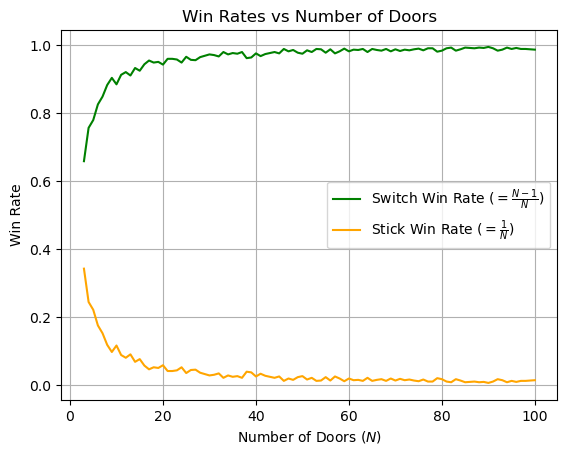

In [10]:
def simulate_generalized_monty(num_simulations=10000, num_doors=4):
    results = []

    for i in range(num_simulations):
        doors = list(range(1, num_doors + 1))
        prize_door = random.choice(doors)
        chosen_door = random.choice(doors)

        # Doors host can open: not the prize door, not the chosen door
        host_options = [door for door in doors if door != prize_door and door != chosen_door]
        doors_host_opens = random.sample(host_options, num_doors - 2)

        # Remaining door besides chosen_door
        remaining_doors = [door for door in doors if door not in doors_host_opens and door != chosen_door]
        switch_door = remaining_doors[0] if remaining_doors else chosen_door

        win_by_sticking = 1 if chosen_door == prize_door else 0
        win_by_switching = 1 if switch_door == prize_door else 0

        results.append({
            "Simulation": i + 1,
            "Prize Door": prize_door,
            "Chosen Door": chosen_door,
            "Win by Sticking": win_by_sticking,
            "Win by Switching": win_by_switching
        })

    return pd.DataFrame(results)

door_counts = list(range(3, 101))
stick_rates = []
switch_rates = []

for n in door_counts:
    df = simulate_generalized_monty(num_simulations=1000, num_doors=n)
    stick_rates.append(df['Win by Sticking'].mean())
    switch_rates.append(df['Win by Switching'].mean())


plt.plot(door_counts, switch_rates, label=r'Switch Win Rate ($ = \frac{N-1}{N}$)', color='green')
plt.plot(door_counts, stick_rates, label=r'Stick Win Rate ($ = \frac{1}{N}$)', color='orange')
plt.title("Win Rates vs Number of Doors")
plt.xlabel(r"Number of Doors $(N)$")
plt.ylabel("Win Rate")
plt.legend()
plt.grid(True)
plt.show()


### Human Bias

To study the impact of human decision-making, we modeled three types of contestant behaviors by **restricting their strategy** in the Monty Hall problem. This version highlights how different biases affect outcomes:

- **Rational Player**: Always switches doors when given the option.
- **Random Player**: Chooses to switch or stick with equal probability (50%).
- **Biased Player**: Prefers sticking — switches with 30% probability and sticks with 70%.

By analyzing these strategies under the standard Monty Hall setup, we demonstrate how suboptimal behavior (e.g., biased or random decision-making) leads to lower win rates compared to the rational, always-switching strategy.

Biased Player Win Rate: 0.4396
Random Player Win Rate: 0.5023
Rational Player Win Rate: 0.6672


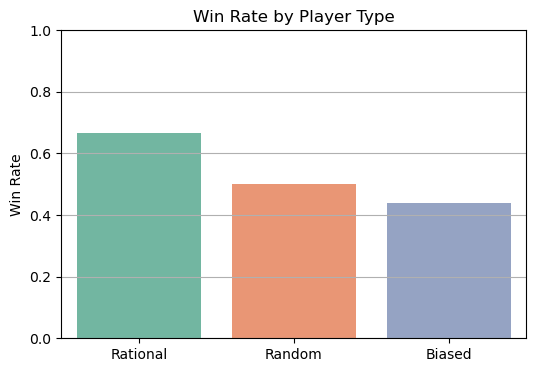

In [11]:
def simulate_with_human_bias(num_simulations=10000, player_type="biased", num_doors=3):
    results = []
    random.seed(42)  # For reproducibility
    
    for i in range(num_simulations):
        doors = list(range(1, num_doors + 1))
        prize_door = random.choice(doors)
        chosen_door = random.choice(doors)

        # Host opens a door that's not the chosen or prize door
        host_options = [door for door in doors if door != chosen_door and door != prize_door]
        door_opened_by_host = random.choice(host_options)

        remaining_doors = [door for door in doors if door != chosen_door and door != door_opened_by_host]
        switch_door = remaining_doors[0] if remaining_doors else chosen_door

        # Decide strategy
        if player_type == "rational":
            switch = True
        elif player_type == "random":
            switch = random.choice([True, False])
        elif player_type == "biased":
            switch = random.choices([False, True], weights=[0.7, 0.3])[0]
        else:
            switch = False  # fallback to sticking

        final_choice = switch_door if switch else chosen_door
        win = 1 if final_choice == prize_door else 0

        results.append({
            "Simulation": i + 1,
            "Prize Door": prize_door,
            "Chosen Door": chosen_door,
            "Strategy": "Switch" if switch else "Stick",
            "Win": win
        })

    return pd.DataFrame(results)

df_biased = simulate_with_human_bias(player_type="biased")
df_random = simulate_with_human_bias(player_type="random")
df_rational = simulate_with_human_bias(player_type="rational")

# Win rates
print("Biased Player Win Rate:", df_biased["Win"].mean())
print("Random Player Win Rate:", df_random["Win"].mean())
print("Rational Player Win Rate:", df_rational["Win"].mean())

# Win rates
win_rates = {
    "Rational": df_rational["Win"].mean(),
    "Random": df_random["Win"].mean(),
    "Biased": df_biased["Win"].mean()
}

plt.figure(figsize=(6, 4))
sns.barplot(x=list(win_rates.keys()), y=list(win_rates.values()), palette="Set2", hue=list(win_rates.keys()))
plt.title("Win Rate by Player Type")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

When simulating human-like decision behavior, we observed that biased players who prefer to stick significantly underperform compared to rational agents. Despite the clear advantage of switching (66.72% win rate), biased players won only 43.96% of the time. This demonstrates how cognitive bias and decision hesitation can reduce optimality in probabilistic games — a phenomenon also seen in real-life Monty Hall experiments.

Below is the distribution of wins of the biased player which follows the theoretical distribution.

Win Rate Distribution (Biased Players):
Switch:  0.6642504118616145
Stick:  0.3417085427135678


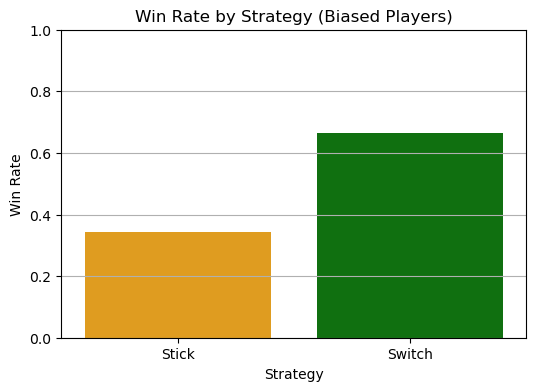

In [12]:
strategy_win_rates = df_biased.groupby("Strategy")["Win"].mean()

# Print Win Rate Distribution
print("Win Rate Distribution (Biased Players):")
print("Switch: ", strategy_win_rates["Switch"])
print("Stick: ", strategy_win_rates["Stick"])

plt.figure(figsize=(6, 4))
sns.barplot(x=strategy_win_rates.index, y=strategy_win_rates.values, palette=["orange", "green"], hue=strategy_win_rates.index)
plt.title("Win Rate by Strategy (Biased Players)")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()


These charts highlight the cost of human-like decision bias. The biased group heavily leans toward sticking, which has a lower win rate. The first plot shows that rational players perform best, while the second confirms that switching is still optimal, even when players don't always choose it.

## 📚 References

1. Rosenhouse, J. (2009). *The Monty Hall Problem: The Remarkable Story of Math's Most Contentious Brain Teaser*. Oxford University Press. [Book Link](https://books.google.com/books?hl=en&lr=&id=6BoTDAAAQBAJ&oi=fnd&pg=PR7&dq=Monty+Hall+Problem+survey&ots=6nA5ep_12k&sig=ZGajWjRYQC4XwTX5Mjn6PRsfES4)

2. Alvarado, R. C. (2024). *What's So Hard about the Monty Hall Problem?* arXiv preprint [arXiv:2405.00884](https://arxiv.org/abs/2405.00884).

3. Adibpour, N., & Morone, A. (2025). *More Doors, More Bias? Cognitive Biases in the Extended Monty Hall Dilemma*. SSRN. [https://doi.org/10.2139/ssrn.5129596](https://doi.org/10.2139/ssrn.5129596)

4. The Monty Hall Problem, Information and Entropy Simulation. (n.d.). Retrieved from [https://dialnet.unirioja.es/servlet/articulo?codigo=9468347](https://dialnet.unirioja.es/servlet/articulo?codigo=9468347)

5. Saenen, L., Heyvaert, M., Van Dooren, W., Schaeken, W., & Onghena, P. (2018). Why humans fail in solving the Monty Hall dilemma: A systematic review. *Psychologica Belgica, 58*(1), 128–158. [https://doi.org/10.5334/pb.274](https://doi.org/10.5334/pb.274)


## Game Play

We demonstrated the Monty Hall Problem using pygame.

In [13]:
!pip install -qq pygame

In [14]:
import pygame
import random

# Init
pygame.init()
WIDTH, HEIGHT = 800, 600
WHITE = (255, 255, 255)
FPS = 60
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Monty Hall Game")
clock = pygame.time.Clock()

# Load & scale images
DOOR_WIDTH, DOOR_HEIGHT = 150, 300
door_img = pygame.transform.scale(pygame.image.load("door.png"), (DOOR_WIDTH, DOOR_HEIGHT))
door_opened_img = pygame.transform.scale(pygame.image.load("goat.png"), (DOOR_WIDTH, DOOR_HEIGHT))
door_with_prize_img = pygame.transform.scale(pygame.image.load("car.png"), (DOOR_WIDTH, DOOR_HEIGHT))

# Fonts
font = pygame.font.SysFont("Arial", 24)

# Setup
doors = ['A', 'B', 'C']
positions = [(100, 150), (325, 150), (550, 150)]  # door x,y positions
rects = [pygame.Rect(x, y, DOOR_WIDTH, DOOR_HEIGHT) for x, y in positions]

# Game state
def reset_game():
    return {
        "prize": random.choice(doors),
        "user_choice": None,
        "monty_door": None,
        "final_choice": None,
        "phase": "choose",  # choose, switch_or_stay, result
        "message": "Pick a door!"
    }

game = reset_game()

# Game loop
running = True
while running:
    screen.fill(WHITE)

    # Draw doors
    for i, door in enumerate(doors):
        x, y = positions[i]
        show_img = door_img

        if game["phase"] == "switch_or_stay" and door == game["monty_door"]:
            show_img = door_opened_img
        elif game["phase"] == "result":
            if door == game["prize"]:
                show_img = door_with_prize_img
            elif door == game["monty_door"]:
                show_img = door_opened_img

        screen.blit(show_img, (x, y))
        pygame.draw.rect(screen, (0, 0, 0), rects[i], 2)

    # Message
    msg = font.render(game["message"], True, (0, 0, 0))
    screen.blit(msg, (50, 30))

    pygame.display.flip()
    clock.tick(FPS)

    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

        # Door click
        if game["phase"] == "choose" and event.type == pygame.MOUSEBUTTONDOWN:
            for i, rect in enumerate(rects):
                if rect.collidepoint(event.pos):
                    game["user_choice"] = doors[i]
                    # Monty opens a goat door not picked by user or hiding prize
                    possibles = [d for d in doors if d != game["user_choice"] and d != game["prize"]]
                    game["monty_door"] = random.choice(possibles)
                    game["phase"] = "switch_or_stay"
                    game["message"] = f"Monty opened a goat door. Press S to switch or D to stay."

        # Key presses for switch or stay
        if game["phase"] == "switch_or_stay" and event.type == pygame.KEYDOWN:
            if event.key == pygame.K_s:
                # Switch to the remaining unopened door
                game["final_choice"] = [d for d in doors if d != game["user_choice"] and d != game["monty_door"]][0]
                game["message"] = "You switched and "
                game["phase"] = "result"
            elif event.key == pygame.K_d:
                game["final_choice"] = game["user_choice"]
                game["message"] = "You stayed and "
                game["phase"] = "result"

            # Add result to message
            if game["phase"] == "result":
                if game["final_choice"] == game["prize"]:
                    game["message"] += "WON! Press Enter to play again."
                else:
                    game["message"] += "lost.Press Enter to play again."

        # Restart after result
        if game["phase"] == "result" and event.type == pygame.KEYDOWN:
            if event.key == pygame.K_RETURN:
                game = reset_game()

pygame.quit()


pygame 2.6.1 (SDL 2.28.4, Python 3.11.3)
Hello from the pygame community. https://www.pygame.org/contribute.html
